In [2]:
import matplotlib.pyplot as plt
from sklearn import datasets
wine=datasets.load_wine()
wine.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [3]:
print(wine['DESCR'])

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

    :Number of Instances: 178
    :Number of Attributes: 13 numeric, predictive attributes and the class
    :Attribute Information:
 		- Alcohol
 		- Malic acid
 		- Ash
		- Alcalinity of ash  
 		- Magnesium
		- Total phenols
 		- Flavanoids
 		- Nonflavanoid phenols
 		- Proanthocyanins
		- Color intensity
 		- Hue
 		- OD280/OD315 of diluted wines
 		- Proline

    - class:
            - class_0
            - class_1
            - class_2
		
    :Summary Statistics:
    
    ============================= ==== ===== ======= =====
                                   Min   Max   Mean     SD
    ============================= ==== ===== ======= =====
    Alcohol:                      11.0  14.8    13.0   0.8
    Malic Acid:                   0.74  5.80    2.34  1.12
    Ash:                          1.36  3.23    2.36  0.27
    Alcalinity of Ash:            10.6  30.0    19.5   3.3
    Ma

In [4]:
print(wine['data'])
print (wine['target'])

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [6]:
import tarfile
import urllib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

preprocessor = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("pca", PCA(n_components=2, random_state=42)),
    ]
)

In [9]:
clusterer = Pipeline(
    [
        (
            "kmeans",
            KMeans(
                n_clusters=3,
                init="k-means++",
                n_init=50,
                max_iter=5000,
                random_state=42,
            ),
        ),
    ]
)

In [10]:
pipe = Pipeline([("preprocessor", preprocessor), ("clusterer", clusterer)])

In [12]:
pipe.fit(wine.data)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', MinMaxScaler()),
                                 ('pca',
                                  PCA(n_components=2, random_state=42))])),
                ('clusterer',
                 Pipeline(steps=[('kmeans',
                                  KMeans(max_iter=5000, n_clusters=3, n_init=50,
                                         random_state=42))]))])

In [13]:
preprocessed_data = pipe["preprocessor"].transform(wine.data)
preprocessed_data

array([[-7.06335756e-01, -2.53192753e-01],
       [-4.84976802e-01, -8.82289142e-03],
       [-5.21172266e-01, -1.89187222e-01],
       [-8.21643663e-01, -5.80905512e-01],
       [-2.02546382e-01, -5.94665740e-02],
       [-6.08190152e-01, -4.87519191e-01],
       [-5.44047399e-01, -3.00196497e-01],
       [-4.74357495e-01, -2.98197021e-01],
       [-5.00432012e-01, -3.07602859e-01],
       [-6.27517969e-01, -2.06328233e-01],
       [-7.27467157e-01, -3.56512044e-01],
       [-3.74967744e-01, -2.25424535e-01],
       [-4.48188283e-01, -2.31938139e-01],
       [-6.26345329e-01, -3.55138677e-01],
       [-8.35717011e-01, -5.38047802e-01],
       [-4.71931568e-01, -3.37405385e-01],
       [-4.26990905e-01, -4.50842684e-01],
       [-3.66595704e-01, -3.15750341e-01],
       [-7.18788533e-01, -5.93881332e-01],
       [-4.58884986e-01, -1.75782240e-01],
       [-6.61852288e-01, -1.27831032e-01],
       [-2.67900032e-01,  9.81127565e-03],
       [-5.99782399e-01,  7.82494523e-04],
       [-4.

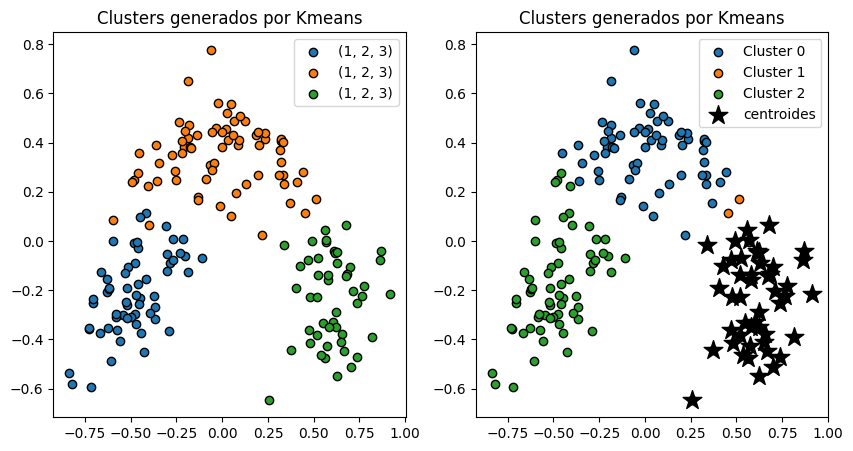

In [24]:
# Clasificación con el modelo kmeans
# ==============================================================================
y_predict = pipe["clusterer"]["kmeans"].labels_

# Representación gráfica: grupos originales vs clusters creados
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Grupos originales
for i in np.unique(wine['target']):
    ax[0].scatter(
        x = preprocessed_data[wine['target'] == i, 0],
        y = preprocessed_data[wine['target'] == i, 1], 
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black', 
        label=(1,2,3)
    )
ax[0].set_title('Clusters generados por Kmeans')
ax[0].legend();

for i in np.unique(pipe["clusterer"]["kmeans"].labels_):
    ax[1].scatter(
        x = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 0],
        y = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 1], 
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black', 
        label= f"Cluster {i}"
    )
    
ax[1].scatter(
   x = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 0],
y = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 1],
    c = 'black',
    s = 200,
    marker = '*',
    label  = 'centroides'
)
ax[1].set_title('Clusters generados por Kmeans')
ax[1].legend();

In [25]:
pd.crosstab(wine['target'], pipe["clusterer"]["kmeans"].labels_, dropna=False, rownames=['grupo_real'], colnames=['cluster'])

cluster,0,1,2
grupo_real,,,
0,0,0,59
1,62,3,6
2,0,48,0


In [39]:
# Empty lists to hold evaluation metrics
silhouette_scores = []
ari_scores = []
for n in range(2, 13):
    # This set the number of components for pca,
    # but leaves other steps unchanged
    pipe["preprocessor"]["pca"].n_components = n
    pipe.fit(wine['data'])

    silhouette_coef = silhouette_score(
        pipe["preprocessor"].transform(wine['data']),
        pipe["clusterer"]["kmeans"].labels_,
    )
    ari = adjusted_rand_score(
        wine['target'],
        pipe["clusterer"]["kmeans"].labels_,
    )


    # Add metrics to their lists
    silhouette_scores.append(silhouette_coef)
    ari_scores.append(ari)

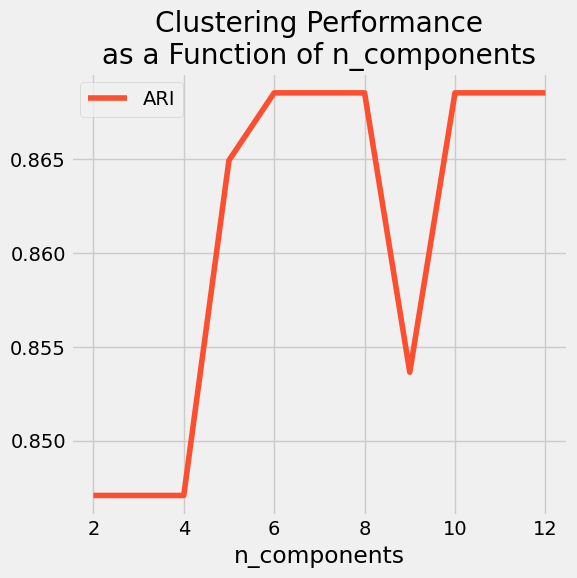

In [41]:
plt.style.use("fivethirtyeight")
plt.figure(figsize=(6, 6))

plt.plot(range(2, 13), ari_scores, c="#fc4f30", label="ARI")
#plt.plot(range(2, 11), inertias, marker='o',label="elbow")

 

plt.xlabel("n_components")
plt.legend()
plt.title("Clustering Performance\nas a Function of n_components")
plt.tight_layout()
plt.show()

In [44]:
pipe["preprocessor"]["pca"].n_components = 10
pipe.fit(wine['data'])

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', MinMaxScaler()),
                                 ('pca',
                                  PCA(n_components=10, random_state=42))])),
                ('clusterer',
                 Pipeline(steps=[('kmeans',
                                  KMeans(max_iter=5000, n_clusters=3, n_init=50,
                                         random_state=42))]))])

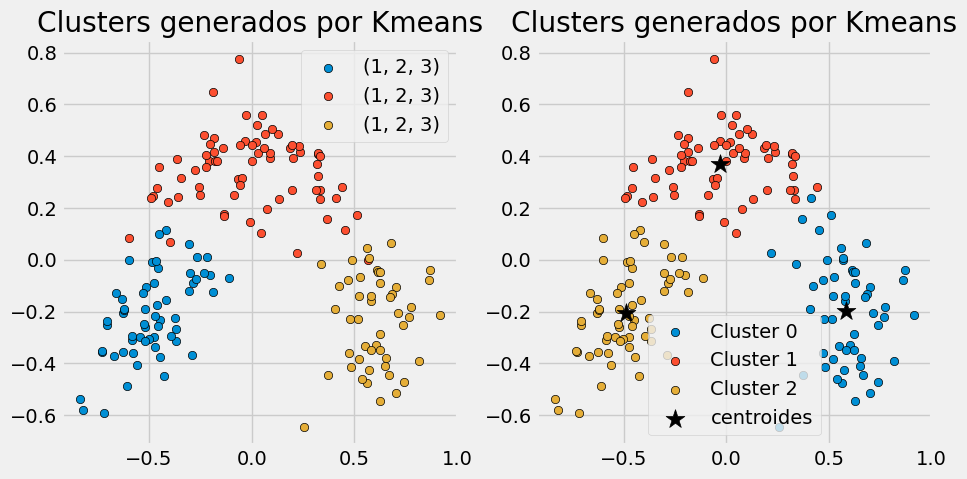

In [47]:
# Clasificación con el modelo kmeans

 

# ==============================================================================

 

y_predict = pipe["clusterer"]["kmeans"].labels_

 

# Representación gráfica: grupos originales vs clusters creados

 

# ==============================================================================

 

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# Grupos originales

 

for i in np.unique(wine['target']):

 

    ax[0].scatter(

 

    
   x = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 0],

 

y = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 1],

 

        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],

 

        marker    = 'o',

 

        edgecolor = 'black',

 

        label=(1,2,3)

 

    )

 

ax[0].set_title('Clusters generados por Kmeans')

 

ax[0].legend();

 

 


for i in np.unique(pipe["clusterer"]["kmeans"].labels_):

 

    ax[1].scatter(

 

        x = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 0],

 

        y = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 1],

 

        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],

 

        marker    = 'o',

 

        edgecolor = 'black',

 

        label= f"Cluster {i}"

 

    )

 

   

 

ax[1].scatter(

 

   x = pipe["clusterer"]["kmeans"].cluster_centers_[:, 0],
    y = pipe["clusterer"]["kmeans"].cluster_centers_[:, 1],

 

    c = 'black',

 

    s = 200,

 

    marker = '*',

 

    label  = 'centroides'

 

)

 

ax[1].set_title('Clusters generados por Kmeans')

 

ax[1].legend();

In [48]:
pd.crosstab(wine['target'], pipe["clusterer"]["kmeans"].labels_, dropna=False, rownames=['grupo_real'], colnames=['cluster'])

cluster,0,1,2
grupo_real,,,
0,0,0,59
1,6,63,2
2,48,0,0


In [69]:

from pyclustering.cluster.center_initializer import random_center_initializer

import math
def distanciaE(point1, point2):
     distance = 0.0
     for i in range(len(point1)):
         distance += (point1[i] - point2[i]) ** 2.0
     return math.sqrt(distance)
def distanciaAVE(point1, point2):
     distance = 0.0
     for i in range(len(point1)):
         distance += (point1[i] - point2[i]) ** 2.0
     return math.sqrt(distance/len(point1))

def distanciaWE(point1, point2):
     #W=(0.4,0.3,0.2,0.1) #86.67
     #W=(0.3,0.2,0.4,0.1) #89.33   
     #W=(0.1,0.2,0.3,0.4) #91.33
     W=(0.1,0.1,0.1,0.7)  #96
     distance = 0.0
     for i in range(len(point1)):
         distance += W[i]*(point1[i] - point2[i]) ** 2.0
     return math.sqrt(distance)


# define dictionary for distance measures
distance_measures = {'Euclidiana': 0, 'Euclidiana cuadrada': 1, 'Manhattan': 2, 'Chebyshev': 3, 
                    'Canberra': 5, 'Chi-square': 6}

X=pipe["preprocessor"].transform(wine['data'])
# function defined to compute purity score using pyclustering for various distance measures
def pyPurity(dist_measure):
    initial_centers = random_center_initializer(X, 3, random_state=5).initialize()
    # instance created for respective distance metric
    if dist_measure!=1000:
        instanceKm = kmeans(X, initial_centers=initial_centers, metric=distance_metric(dist_measure))
    else:
        instanceKm = kmeans(X, initial_centers=initial_centers, metric=distance_metric(1000, func=distanciaWE))
    # perform cluster analysis
    instanceKm.process()
    # cluster analysis results - clusters and centers
    pyClusters = instanceKm.get_clusters()
    pyCenters = instanceKm.get_centers()
    # enumerate encoding type to index labeling to get labels
    pyEncoding = instanceKm.get_cluster_encoding()
    pyEncoder = cluster_encoder(pyEncoding, pyClusters, X)
    pyLabels = pyEncoder.set_encoding(0).get_clusters()
    # function purity score is defined in previous section
    return purity_score(y, pyLabels)

# print results
for measure, value in distance_measures.items():
    print(f"Purity score con distancia {measure}: {round(pyPurity(value)*100, 2)}%")

SyntaxError: ignored

In [70]:
pip install pyclustering

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 24.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395106 sha256=2527755bddca8fd20a0826345b6cf6ec2217b4920b1868f56e0b1b62477fcef6
  Stored in directory: /root/.cache/pip/wheels/b5/42/97/11eee99f5c1e4fdfc170f0a54f9c9eb195df66edb4cf69f449
Successfully built pyclustering


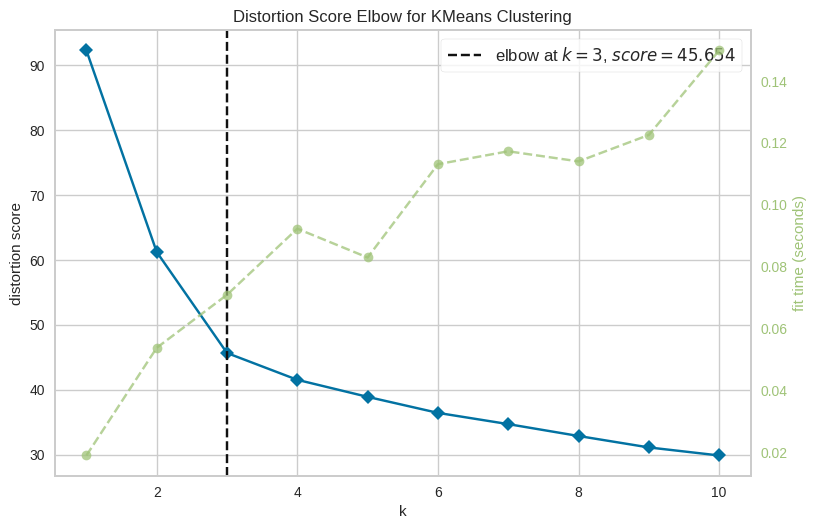

The purity score is cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Euclidiana: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Euclidiana cuadrada: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Manhattan: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Chebyshev: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Canberra: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Chi-square: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%


In [88]:
from pyclustering.cluster.kmeans import kmeans
from pyclustering.utils.metric import distance_metric
from pyclustering.cluster.center_initializer import random_center_initializer
from pyclustering.cluster.encoder import type_encoding
from pyclustering.cluster.encoder import cluster_encoder
# sklearn kmeans
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import contingency_matrix
 #data visualization
import matplotlib.pyplot as plt
%matplotlib inline
from yellowbrick.cluster import KElbowVisualizer # cluster visualizer


import math
X=pipe["preprocessor"].transform(wine['data'])
y = pipe["preprocessor"].transform(wine['data'])
# Instantiate the clustering model and visualizer
model = KMeans(n_init=50)
visualizer = KElbowVisualizer(model, k=(1, 11))

visualizer.fit(X) # Fit the data to the visualizer
visualizer.show() # Finalize and render the figure
plt.show()
def purity_score(y_true, y_pred):
    # compute contingency matrix (also called confusion matrix)
    confusion_matrix = pd.crosstab(wine['target'], pipe["clusterer"]["kmeans"].labels_, dropna=False, rownames=['grupo_real'], colnames=['cluster'])
    # return purity
    return np.sum(np.amax(confusion_matrix, axis=0)) / np.sum(confusion_matrix)
# instatiate KMeans class and set the number of clusters
km_model = KMeans(n_clusters=3, random_state=10, n_init=50)

# call fit method with data 
km = km_model.fit_predict(X)

# coordinates of cluster center
centroids = km_model.cluster_centers_ 

# cluster label for each data point
labels = km_model.labels_ 
# Report Purity Score
purity = purity_score(y, labels)
print(f"The purity score is {round(purity*100, 2)}%")

def distanciaE(point1, point2):
     distance = 0.0
     for i in range(len(point1)):
         distance += (point1[i] - point2[i]) ** 2.0
     return math.sqrt(distance)
def distanciaAVE(point1, point2):
     distance = 0.0
     for i in range(len(point1)):
         distance += (point1[i] - point2[i]) ** 2.0
     return math.sqrt(distance/len(point1))

def distanciaWE(point1, point2):
     W=(0.4,0.3,0.2,0.1) #86.67
     W=(0.3,0.2,0.4,0.1) #89.33   
     W=(0.1,0.2,0.3,0.4) #91.33
     W=(0.1,0.1,0.1,0.7)  #96
     distance = 0.0
     for i in range(len(point1)):
         distance += W[i]*(point1[i] - point2[i]) ** 2.0
     return math.sqrt(distance)


# define dictionary for distance measures
distance_measures = {'Euclidiana': 0, 'Euclidiana cuadrada': 1, 'Manhattan': 2, 'Chebyshev': 3, 
                    'Canberra': 5, 'Chi-square': 6}


# function defined to compute purity score using pyclustering for various distance measures
def pyPurity(dist_measure):
    initial_centers = random_center_initializer(X, 3, random_state=5).initialize()
    # instance created for respective distance metric
    if dist_measure!=1000:
        instanceKm = kmeans(X, initial_centers=initial_centers, metric=distance_metric(dist_measure))
    else:
        instanceKm = kmeans(X, initial_centers=initial_centers, metric=distance_metric(1000, func=distanciaWE))
    # perform cluster analysis
    instanceKm.process()
    # cluster analysis results - clusters and centers
    pyClusters = instanceKm.get_clusters()
    pyCenters = instanceKm.get_centers()
    # enumerate encoding type to index labeling to get labels
    pyEncoding = instanceKm.get_cluster_encoding()
    pyEncoder = cluster_encoder(pyEncoding, pyClusters, X)
    pyLabels = pyEncoder.set_encoding(0).get_clusters()
    # function purity score is defined in previous section
    return purity_score(y, pyLabels)

# print results
for measure, value in distance_measures.items():
    print(f"Purity score con distancia {measure}: {round(pyPurity(value)*100, 2)}%")